In [36]:
import numpy as np
from dataclasses import dataclass
from typing import List, Tuple
import matplotlib.pyplot as plt

Data class model init

In [37]:
Edge = Tuple[int, int]

@dataclass(frozen=True)
class Fragment:
    n_sites: int
    edges: List[Edge]
    t: float
    eps: np.ndarray   # on-site energies

In [38]:
N = 6
t = 1.0

# On-site energies (graphene ideal = 0)
eps = np.zeros(N)

edges = [(0,1),(1,2),(2,3),(3,4),(4,5),(5,0)]

fragment = Fragment(
    n_sites=N,
    edges=edges,
    t=t,
    eps=eps
)


Validation for fragment

In [39]:
def validate_fragment(fragment: Fragment):
    N = fragment.n_sites
    for i, j in fragment.edges:
        if not (0 <= i < N and 0 <= j < N):
            raise ValueError(f"Edge {(i,j)} invalid")
        if i == j:
            raise ValueError("Self-loop not allowed")
    if len(fragment.eps) != N:
        raise ValueError("eps length must equal n_sites")

validate_fragment(fragment)
print("Fragment validated.")

Fragment validated.


In [40]:
def build_hamiltonian(fragment: Fragment):
    N = fragment.n_sites
    H = np.zeros((N, N), dtype=float)

    # Diagonal (on-site energies)
    np.fill_diagonal(H, fragment.eps)

    # Off-diagonal hopping
    for i, j in fragment.edges:
        H[i, j] = -fragment.t
        H[j, i] = -fragment.t

    return H

H = build_hamiltonian(fragment)
H

array([[ 0., -1.,  0.,  0.,  0., -1.],
       [-1.,  0., -1.,  0.,  0.,  0.],
       [ 0., -1.,  0., -1.,  0.,  0.],
       [ 0.,  0., -1.,  0., -1.,  0.],
       [ 0.,  0.,  0., -1.,  0., -1.],
       [-1.,  0.,  0.,  0., -1.,  0.]])

In [41]:
energies, eigenvectors = np.linalg.eigh(H)

print("Eigenvalues:")
print(np.sort(energies))

print("\nGround state energy:", np.min(energies))
print("Highest energy:", np.max(energies))

Eigenvalues:
[-2. -1. -1.  1.  1.  2.]

Ground state energy: -1.9999999999999998
Highest energy: 2.0


expected output (for t=1):
[-2. -1. -1.  1.  1.  2.]

Eigenvectors + “wave patterns” plot

In [42]:
# 1) eigen-decomposition (eigenvalues + eigenvectors)
# Diagonalize the Hamiltonian
energies, eigenvectors = np.linalg.eigh(H)

print("Eigenvalues:")
for i, E in enumerate(energies):
    print(f"E_{i} = {E:.6f}")

print("\nEigenvectors (columns of the matrix):")
print(eigenvectors)   # energies sorted ascending already

# 2) coordinates for the hexagon
coords = {
    0: (1.0, 0.0),
    1: (0.5, np.sqrt(3)/2),
    2: (-0.5, np.sqrt(3)/2),
    3: (-1.0, 0.0),
    4: (-0.5, -np.sqrt(3)/2),
    5: (0.5, -np.sqrt(3)/2),
}

# edges for drawing bonds
edges = fragment.edges


Eigenvalues:
E_0 = -2.000000
E_1 = -1.000000
E_2 = -1.000000
E_3 = 1.000000
E_4 = 1.000000
E_5 = 2.000000

Eigenvectors (columns of the matrix):
[[-4.08248290e-01  5.77350269e-01 -0.00000000e+00  5.77350269e-01
   0.00000000e+00  4.08248290e-01]
 [-4.08248290e-01  2.88675135e-01  5.00000000e-01 -2.88675135e-01
  -5.00000000e-01 -4.08248290e-01]
 [-4.08248290e-01 -2.88675135e-01  5.00000000e-01 -2.88675135e-01
   5.00000000e-01  4.08248290e-01]
 [-4.08248290e-01 -5.77350269e-01  1.08537196e-16  5.77350269e-01
  -4.64133203e-17 -4.08248290e-01]
 [-4.08248290e-01 -2.88675135e-01 -5.00000000e-01 -2.88675135e-01
  -5.00000000e-01  4.08248290e-01]
 [-4.08248290e-01  2.88675135e-01 -5.00000000e-01 -2.88675135e-01
   5.00000000e-01 -4.08248290e-01]]


In [43]:
print("Detailed eigenvector analysis:\n")

for k in range(len(energies)):
    print(f"State {k}")
    print(f"Energy E_{k} = {energies[k]:.6f}")
    print("Eigenvector components:")
    
    psi = eigenvectors[:, k]
    for i, amp in enumerate(psi):
        print(f"  Site {i}: amplitude = {amp:.6f}, probability = {abs(amp)**2:.6f}")
    
    print(f"  Total probability = {np.sum(np.abs(psi)**2):.6f}")
    print("-" * 40)

Detailed eigenvector analysis:

State 0
Energy E_0 = -2.000000
Eigenvector components:
  Site 0: amplitude = -0.408248, probability = 0.166667
  Site 1: amplitude = -0.408248, probability = 0.166667
  Site 2: amplitude = -0.408248, probability = 0.166667
  Site 3: amplitude = -0.408248, probability = 0.166667
  Site 4: amplitude = -0.408248, probability = 0.166667
  Site 5: amplitude = -0.408248, probability = 0.166667
  Total probability = 1.000000
----------------------------------------
State 1
Energy E_1 = -1.000000
Eigenvector components:
  Site 0: amplitude = 0.577350, probability = 0.333333
  Site 1: amplitude = 0.288675, probability = 0.083333
  Site 2: amplitude = -0.288675, probability = 0.083333
  Site 3: amplitude = -0.577350, probability = 0.333333
  Site 4: amplitude = -0.288675, probability = 0.083333
  Site 5: amplitude = 0.288675, probability = 0.083333
  Total probability = 1.000000
----------------------------------------
State 2
Energy E_2 = -1.000000
Eigenvector co

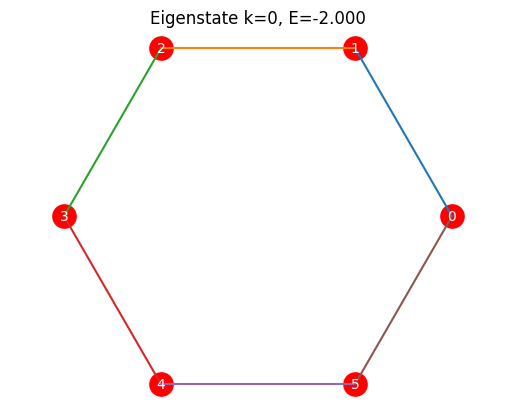

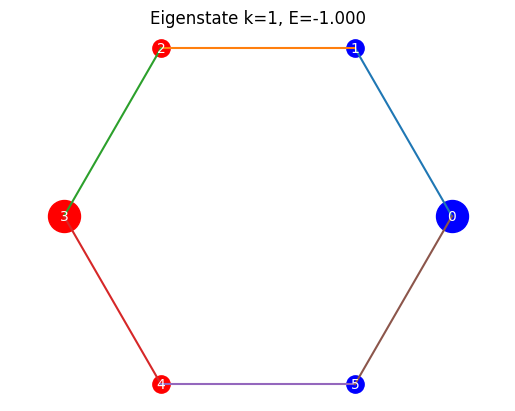

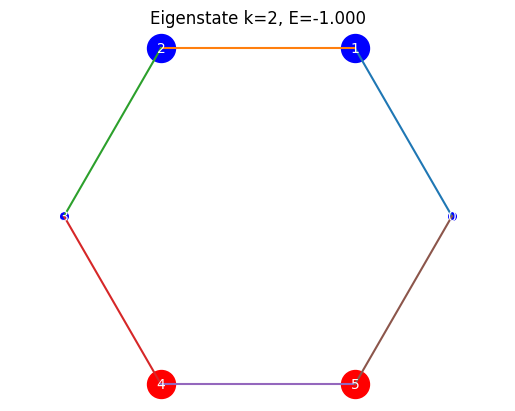

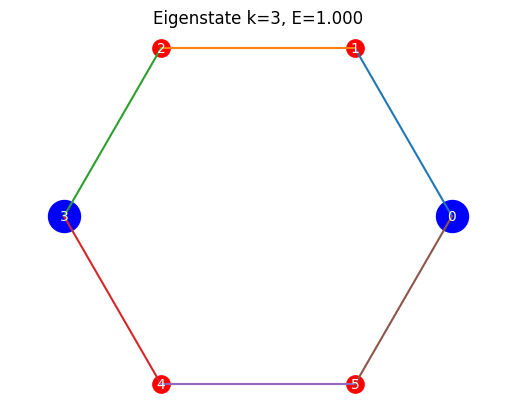

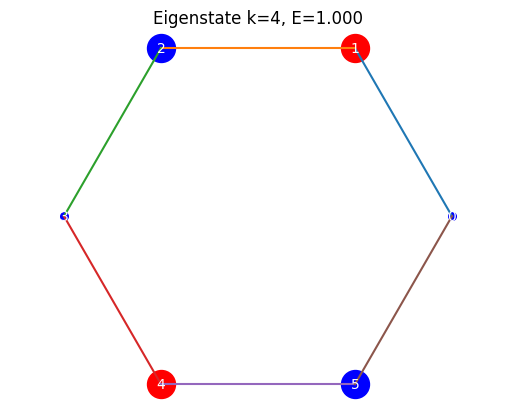

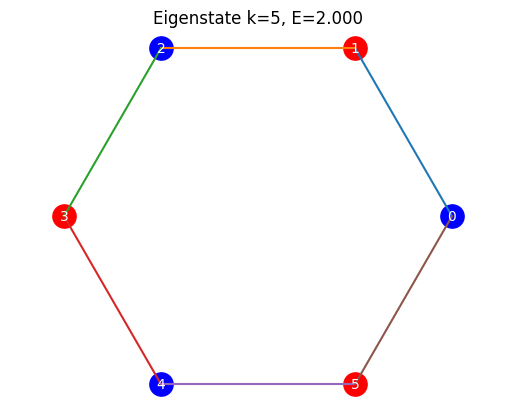

In [44]:
def plot_state(k):
    psi = eigenvectors[:, k]
    amp = np.abs(psi)
    sign = np.sign(psi + 1e-12)

    for i, j in fragment.edges:
        plt.plot([coords[i][0], coords[j][0]],
                 [coords[i][1], coords[j][1]])

    for i in range(fragment.n_sites):
        x, y = coords[i]
        size = 1500 * (amp[i]**2 + 0.02)
        color = "blue" if sign[i] >= 0 else "red"
        plt.scatter(x, y, s=size, color=color)
        plt.text(x, y, str(i), ha="center", va="center", color="white")

    plt.title(f"Eigenstate k={k}, E={energies[k]:.3f}")
    plt.axis("equal")
    plt.axis("off")
    plt.show()

for k in range(fragment.n_sites):
    plot_state(k)

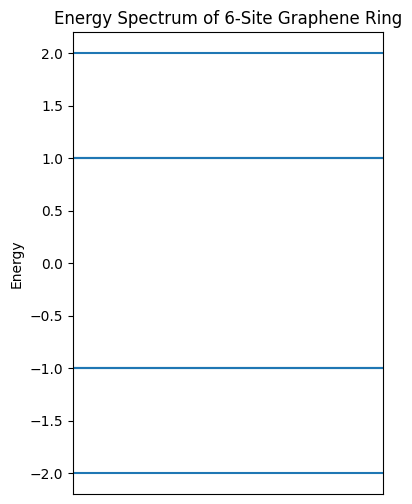

In [45]:
plt.figure(figsize=(4,6))

for E in energies:
    plt.hlines(E, 0, 1)

plt.xlim(0, 1)
plt.xticks([])
plt.ylabel("Energy")
plt.title("Energy Spectrum of 6-Site Graphene Ring")
plt.show()

In [46]:
print("Hamiltonian matrix:")
print(H)

print("\nIs H symmetric?", np.allclose(H, H.T))
print("Trace of H =", np.trace(H))
print("Determinant of H =", np.linalg.det(H))

Hamiltonian matrix:
[[ 0. -1.  0.  0.  0. -1.]
 [-1.  0. -1.  0.  0.  0.]
 [ 0. -1.  0. -1.  0.  0.]
 [ 0.  0. -1.  0. -1.  0.]
 [ 0.  0.  0. -1.  0. -1.]
 [-1.  0.  0.  0. -1.  0.]]

Is H symmetric? True
Trace of H = 0.0
Determinant of H = -4.0


future update to quantum circuit with qubits mapping 

In [47]:
U = 2.0  # interaction strength
print("Next step: implement Hubbard model with U =", U)

Next step: implement Hubbard model with U = 2.0


We will use Qiskit Nature.

In [48]:
# pip install qiskit-nature if needed

-------UPDATED VERSION-----

for 6site mapping to qubits were using the rule: 2^n -> where n is the number of qubits, and the mapping is as follows:

|000> -> site 0
|001> -> site 1
|010> -> site 2
|011> -> site 3
|100> -> site 4
|101> -> site 5

In [49]:
import numpy as np
from scipy.linalg import expm
from qiskit import QuantumCircuit
from qiskit.circuit.library import UnitaryGate
from qiskit.quantum_info import Statevector

In [50]:
# 6 site graphene Hamiltonian matrix
t = 1.0
H6 = np.array([
    [0,-t,0,0,0,-t],
    [-t,0,-t,0,0,0],
    [0,-t,0,-t,0,0],
    [0,0,-t,0,-t,0],
    [0,0,0,-t,0,-t],
    [-t,0,0,0,-t,0]
], dtype=complex)

In [51]:
print("H6 =")
print(H6)
print("Is H6 Hermitian?", np.allclose(H6, H6.conj().T))
print("Dimensions:", H6.shape)

H6 =
[[ 0.+0.j -1.+0.j  0.+0.j  0.+0.j  0.+0.j -1.+0.j]
 [-1.+0.j  0.+0.j -1.+0.j  0.+0.j  0.+0.j  0.+0.j]
 [ 0.+0.j -1.+0.j  0.+0.j -1.+0.j  0.+0.j  0.+0.j]
 [ 0.+0.j  0.+0.j -1.+0.j  0.+0.j -1.+0.j  0.+0.j]
 [ 0.+0.j  0.+0.j  0.+0.j -1.+0.j  0.+0.j -1.+0.j]
 [-1.+0.j  0.+0.j  0.+0.j  0.+0.j -1.+0.j  0.+0.j]]
Is H6 Hermitian? True
Dimensions: (6, 6)


In [52]:
H8 = np.zeros((8,8), dtype=complex)
H8[:6, :6] = H6
print(H8)
print("New dimensions:", H8.shape)

[[ 0.+0.j -1.+0.j  0.+0.j  0.+0.j  0.+0.j -1.+0.j  0.+0.j  0.+0.j]
 [-1.+0.j  0.+0.j -1.+0.j  0.+0.j  0.+0.j  0.+0.j  0.+0.j  0.+0.j]
 [ 0.+0.j -1.+0.j  0.+0.j -1.+0.j  0.+0.j  0.+0.j  0.+0.j  0.+0.j]
 [ 0.+0.j  0.+0.j -1.+0.j  0.+0.j -1.+0.j  0.+0.j  0.+0.j  0.+0.j]
 [ 0.+0.j  0.+0.j  0.+0.j -1.+0.j  0.+0.j -1.+0.j  0.+0.j  0.+0.j]
 [-1.+0.j  0.+0.j  0.+0.j  0.+0.j -1.+0.j  0.+0.j  0.+0.j  0.+0.j]
 [ 0.+0.j  0.+0.j  0.+0.j  0.+0.j  0.+0.j  0.+0.j  0.+0.j  0.+0.j]
 [ 0.+0.j  0.+0.j  0.+0.j  0.+0.j  0.+0.j  0.+0.j  0.+0.j  0.+0.j]]
New dimensions: (8, 8)


#calculating the unitary matrix U


In [53]:
tau = 0.5
U = expm(-1j * H8 * tau)
print("Shape του U:", U.shape)
print("U†U = I ?", np.allclose(U.conj().T @ U, np.eye(8)))

Shape του U: (8, 8)
U†U = I ? True


#mapping it as a unitary gate and mapping it to a quantum circuit

In [54]:
U_gate = UnitaryGate(U, label="e^{-iHt}")
qc = QuantumCircuit(3)
qc.append(U_gate, [0,1,2])
qc.draw("text")

┌───────────┐
q_0: ┤0          ├
     │           │
q_1: ┤1 e^{-iHt} ├
     │           │
q_2: ┤2          ├
     └───────────┘

#we have encoded the lattice in a unitary gate now we can use it to simulate the time evolution of the system


#and now were testing the time evolution of the system with an example of a state |000> state 0 is the initial state 

In [55]:
psi0 = Statevector.from_label("000")
psi_final = psi0.evolve(qc)
print(psi_final)

Statevector([ 0.76515581+0.j        ,  0.        +0.44029884j,
             -0.11242675+0.j        ,  0.        -0.0391267j ,
             -0.11242675+0.j        ,  0.        +0.44029884j,
              0.        +0.j        ,  0.        +0.j        ],
            dims=(2, 2, 2))


---------more updates coming soon!---------------